<a href="https://colab.research.google.com/github/jasonkjw/daily_coding_commit/blob/main/TRS_gen_program.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[Horizontal] Matching iteration starting (Target + 14% Margin)...
[Vertical] Matching iteration starting (Target + 14% Margin)...


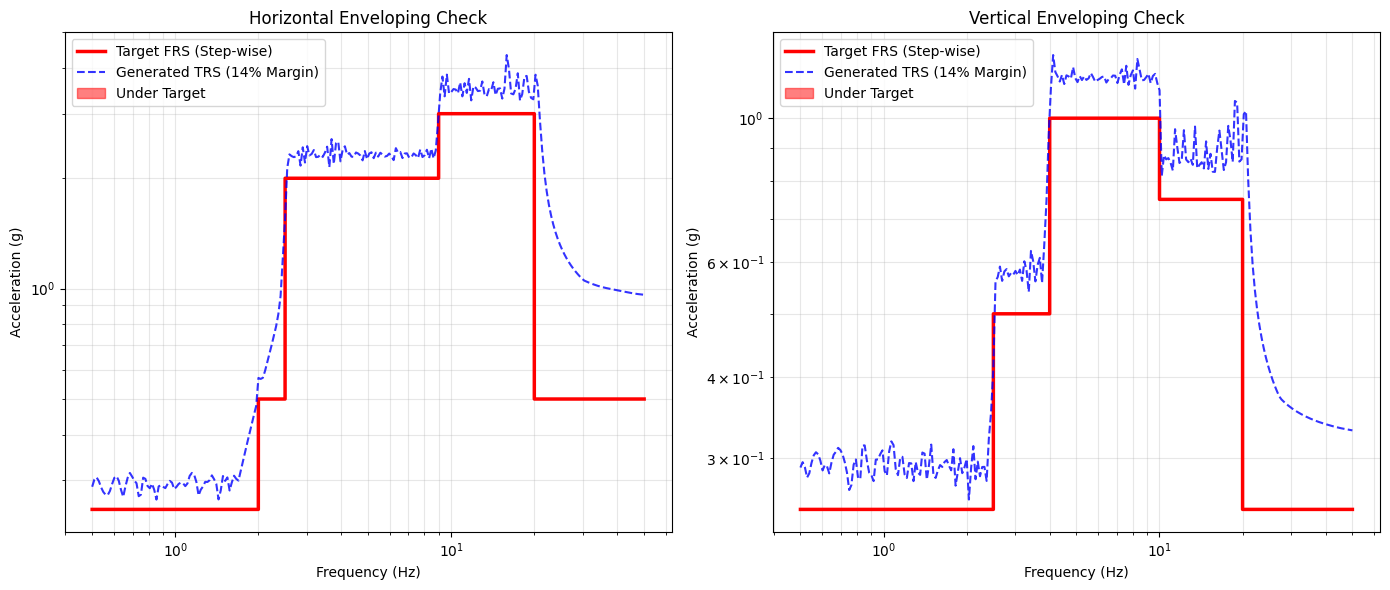


[성공] 모든 과정이 완료되었습니다.
1. Horizontal Max Accel: 9063.34 mm/s^2
2. Vertical Max Accel: 3131.61 mm/s^2
3. 저장된 파일: 'ATH_Final_Horizontal_mm.csv', 'ATH_Final_Vertical_mm.csv'


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. 상수 및 단위 설정
# ==========================================
G_TO_MM_S2 = 9806.6  # g -> mm/s^2 변환
DT = 0.005           # 타임 스텝 (200Hz)
DURATION = 20.48     # 전체 시간
DAMPING = 0.02       # 2% 감쇠비
MARGIN = 1.15        # FRS 대비 15% 여유치 확보 (포괄성 보증)

# ==========================================
# 2. 계단식 FRS 정의 (수직 구간 구현을 위한 미세 차이)
# ==========================================
# Horizontal Target
h_freq = np.array([0.5, 2.0, 2.001, 2.5, 2.501, 9.0, 9.001, 20.0, 20.001, 50.0])
h_accel = np.array([0.25, 0.25, 0.5, 0.5, 2.0, 2.0, 3.0, 3.0, 0.5, 0.5])

# Vertical Target
v_freq = np.array([0.5, 2.0, 2.001, 2.5, 2.501, 4.0, 4.001, 10.0, 10.001, 20.0, 20.001, 50.0])
v_accel = np.array([0.25, 0.25, 0.25, 0.25, 0.5, 0.5, 1.0, 1.0, 0.75, 0.75, 0.25, 0.25])

# ==========================================
# 3. Newmark-beta 응답 스펙트럼 계산 함수
# ==========================================
def calculate_rs(accel, dt, damping, freqs):
    sa = np.zeros(len(freqs))
    beta, gamma = 0.25, 0.5
    for i, f in enumerate(freqs):
        w = 2 * np.pi * f
        m, k, c = 1.0, w**2, 2 * w * damping
        u, v, a_rel = 0.0, 0.0, -accel[0]
        max_a = 0.0
        keff = k + m/(beta * dt**2) + c * gamma/(beta * dt)

        for j in range(len(accel) - 1):
            df = -(accel[j+1] - accel[j]) + (m/(beta*dt) + c*gamma/beta)*v + (m/(2*beta) + dt*c*(gamma/(2*beta)-1))*a_rel
            du = df / keff
            dv = (gamma/(beta*dt))*du - (gamma/beta)*v + dt*(1 - gamma/(2*beta))*a_rel
            da = (1/(beta*dt**2))*du - (1/(beta*dt))*v - (1/(2*beta))*a_rel
            u += du; v += dv; a_rel += da
            total_a = np.abs(a_rel + accel[j+1])
            if total_a > max_a: max_a = total_a
        sa[i] = max_a
    return sa

# ==========================================
# 4. 엄격한 포괄(Strict Enveloping) ATH 생성 함수
# ==========================================
def get_matched_ath_strict(target_f, target_a, name=""):
    t = np.arange(0, DURATION, DT)
    n = len(t)
    np.random.seed(42 if "Hor" in name else 123)

    # 초기 파형 및 시간 영역 엔벨로프 적용
    wave = np.random.normal(0, 0.1, n)
    envelope = np.where(t < 2.0, (t/2.0)**2, np.where(t < 15.0, 1.0, np.exp(-0.8 * (t - 15.0))))
    wave *= envelope

    # 평가 주파수 설정 (계단 구간 포착을 위해 촘촘하게 설정)
    eval_freqs = np.geomspace(0.5, 50, 250)
    target_interp = np.interp(eval_freqs, target_f, target_a)

    # 실제 타겟보다 높은 Strict Target 설정
    strict_target = target_interp * MARGIN

    print(f"[{name}] Matching iteration starting (Target + {int((MARGIN-1)*100)}% Margin)...")

    for i in range(40):
        trs = calculate_rs(wave, DT, DAMPING, eval_freqs)

        # 부족한 곳은 강하게(1.5승), 넘치는 곳은 약하게(0.8승) 보정
        ratio = strict_target / (trs + 1e-6)
        ratio = np.where(ratio > 1.0, ratio**1.5, ratio**0.8)

        # 주파수 영역 보정 (FFT)
        fft_val = np.fft.rfft(wave)
        fft_freq = np.fft.rfftfreq(n, d=DT)
        ratio_interp = np.interp(fft_freq, eval_freqs, ratio)

        fft_val *= np.clip(ratio_interp, 0.1, 5.0)
        wave = np.fft.irfft(fft_val, n)

        # 엔벨로프 재적용
        wave *= envelope

        # 매 루프마다 '절대 하한선' 체크: 단 한 점이라도 FRS 아래면 전체 증폭
        current_trs = calculate_rs(wave, DT, DAMPING, eval_freqs)
        lack_ratio = np.max(target_interp / (current_trs + 1e-9))
        if lack_ratio > 1.0:
            wave *= (lack_ratio * 1.02) # 최소 2%의 안전마진 추가 확보

    return wave, eval_freqs, calculate_rs(wave, DT, DAMPING, eval_freqs)

# ==========================================
# 5. 실행 및 결과 저장
# ==========================================
# 지진파 생성
ath_h_g, f_h, trs_h_g = get_matched_ath_strict(h_freq, h_accel, "Horizontal")
ath_v_g, f_v, trs_v_g = get_matched_ath_strict(v_freq, v_accel, "Vertical")

# mm/s^2 단위 변환
ath_h_mm = ath_h_g * G_TO_MM_S2
ath_v_mm = ath_v_g * G_TO_MM_S2

# CSV 저장 (Ansys용)
t_axis = np.arange(0, DURATION, DT)
pd.DataFrame({'Time': t_axis, 'Accel_mm_s2': ath_h_mm}).to_csv('ATH_Final_Horizontal_mm.csv', index=False)
pd.DataFrame({'Time': t_axis, 'Accel_mm_s2': ath_v_mm}).to_csv('ATH_Final_Vertical_mm.csv', index=False)

# ==========================================
# 6. 시각화 (성능 확인) - ValueError 수정 버전
# ==========================================
plt.figure(figsize=(14, 6))

for i, (f, trs, tf, ta, title) in enumerate([
    (f_h, trs_h_g, h_freq, h_accel, "Horizontal"),
    (f_v, trs_v_g, v_freq, v_accel, "Vertical")
]):
    plt.subplot(1, 2, i+1)

    # [수정 포인트] 시각화를 위해 타겟 가속도를 평가 주파수(f) 크기에 맞춰 보간합니다.
    ta_interp = np.interp(f, tf, ta)

    # 1. 타겟 FRS (원래 꺾임점 기준)
    plt.loglog(tf, ta, 'r-', lw=2.5, label='Target FRS (Step-wise)')

    # 2. 생성된 TRS (250개 포인트)
    plt.loglog(f, trs, 'b--', alpha=0.8, label=f'Generated TRS ({int((MARGIN-1)*100)}% Margin)')

    # 3. 포괄성 위반 구간 시각화 (보간된 ta_interp와 250개 규격 맞춰 비교)
    plt.fill_between(f, ta_interp, trs, where=(trs < ta_interp), color='red', alpha=0.5, label='Under Target')

    plt.title(f"{title} Enveloping Check")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Acceleration (g)")
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

print("\n[성공] 모든 과정이 완료되었습니다.")
print(f"1. Horizontal Max Accel: {np.max(np.abs(ath_h_mm)):.2f} mm/s^2")
print(f"2. Vertical Max Accel: {np.max(np.abs(ath_v_mm)):.2f} mm/s^2")
print("3. 저장된 파일: 'ATH_Final_Horizontal_mm.csv', 'ATH_Final_Vertical_mm.csv'")